In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
torch.manual_seed(42)

# Data Load

In [6]:
df = pd.read_csv("2  powerplant_data.csv")

In [7]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [8]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [9]:
X = df.drop(['PE'],axis=1)
y = df['PE']

# Train Test split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_test.shape

(1914, 4)

In [12]:
y_test

2513    433.27
9411    438.16
8745    458.42
9085    480.82
4950    441.41
         ...  
7204    456.70
1599    438.04
5697    467.80
350     437.14
6210    456.78
Name: PE, Length: 1914, dtype: float64

In [13]:
scaler = StandardScaler()

X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

# Converting into tensors

In [14]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

# TensorDataset and DataLoader

In [15]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

# Define ANN  model

In [17]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),
        #2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        # ouutput
        nn.Linear(6,1)
    )
    # forward pass
  def forward(self,x):
    return  self.model(x)



In [18]:
model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Train the ANN model

In [19]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0

  for batch_features, batch_labels in train_loader:
    outputs = model(batch_features)

    optimizer.zero_grad()
    #loss calculation
    loss = criterion(outputs,batch_labels)
    # backward
    loss.backward()
    # parameters update
    optimizer.step()

    running_loss = running_loss + loss.item()

  total_loss = running_loss / len(train_loader)
  train_losses.append(total_loss)


  # validation loss
  model.eval()
  running_val_loss = 0.0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      outputs = model(batch_features)

      #loss calculation
      loss = criterion(outputs,batch_labels)

      running_loss = running_loss + loss

  total_val_loss = running_loss / len(test_loader)

  val_losses.append(total_val_loss)


  print(f"Epoch : {epoch + 1}/{epochs},Training Loss : {total_loss}, val Loss :{total_val_loss}")

  if total_val_loss < best_val_loss:
    best_val_loss = total_val_loss
    torch.save(model.state_dict(),"best_model.pt")



Epoch : 1/100,Training Loss : 205893.85807291666, val Loss :1027846.375
Epoch : 2/100,Training Loss : 199899.0625, val Loss :992370.625
Epoch : 3/100,Training Loss : 180244.65540364583, val Loss :885764.125
Epoch : 4/100,Training Loss : 144655.2404296875, val Loss :701793.0625
Epoch : 5/100,Training Loss : 101024.1780110677, val Loss :484121.1875
Epoch : 6/100,Training Loss : 62692.352311197916, val Loss :299177.03125
Epoch : 7/100,Training Loss : 38906.72813313802, val Loss :187332.640625
Epoch : 8/100,Training Loss : 27443.56181233724, val Loss :133824.5625
Epoch : 9/100,Training Loss : 21995.212626139324, val Loss :107986.34375
Epoch : 10/100,Training Loss : 18664.122196451823, val Loss :91749.625
Epoch : 11/100,Training Loss : 15942.834395345051, val Loss :78247.5
Epoch : 12/100,Training Loss : 13339.304223632813, val Loss :65284.46484375
Epoch : 13/100,Training Loss : 10802.027657063802, val Loss :52687.7734375
Epoch : 14/100,Training Loss : 8445.474314371744, val Loss :40991.6328

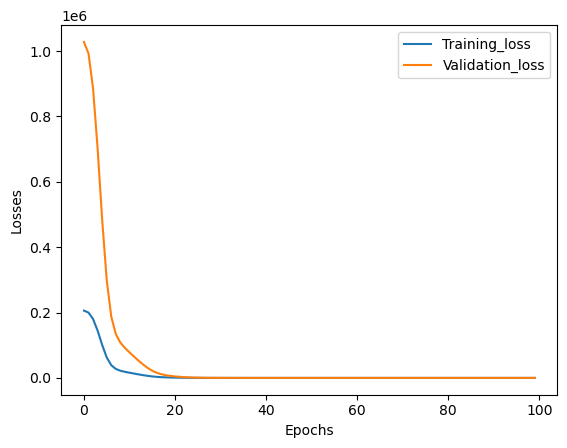

In [20]:
loss_df = pd.DataFrame({
    "Training_Loss" : train_losses,
    "Validation_Loss" : val_losses
}
)

plt.plot(loss_df['Training_Loss'],label = "Training_loss")
plt.plot(loss_df['Validation_Loss'],label = "Validation_loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

# Loading the best model

In [21]:
model.load_state_dict(torch.load('best_model.pt'))

<All keys matched successfully>

# Evaluate the Model

In [22]:
model.eval()

with torch.no_grad():
  train_preds = model(X_train_tensor)
  test_preds = model(X_test_tensor)

  train_mse = criterion(train_preds,y_train_tensor)
  test_mse = criterion(test_preds,y_test_tensor)

print(f"Training MSE : {train_mse}.item()")
print(f"Testing MSE : {test_mse}.item()")



Training MSE : 20.846620559692383.item()
Testing MSE : 19.237089157104492.item()


In [23]:
print(f"R2 Score : {r2_score(y_test,test_preds)}")

R2 Score : 0.9327713347574583
